# Benchmark B — RoBERTa Résumé Named Entity Recognition

This notebook directly continues `01_data_preparation.ipynb`. It loads its saved train/validation/test JSON files, converts character-level résumé annotations to BIO token labels, fine-tunes `roberta-base`, and reports test-set performance.

**Run order:** complete notebook 01 first, then run this notebook from top to bottom.

## 1. Environment and reproducibility

In [ ]:
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import inspect
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from datasets import Dataset
from seqeval.metrics import accuracy_score, classification_report, f1_score, precision_score, recall_score
from transformers import (
    AutoModelForTokenClassification,
    AutoTokenizer,
    DataCollatorForTokenClassification,
    Trainer,
    TrainingArguments,
    set_seed,
)

SEED = 42
MODEL_NAME = "roberta-base"
MAX_LENGTH = 512

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)

print("PyTorch device:", "cuda" if torch.cuda.is_available() else "cpu")

PyTorch device: cpu


## 2. Load the output of `01_data_preparation.ipynb`

In [ ]:
# This works whether Jupyter starts in the repository root or in notebooks/.
cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd if (cwd / "data").is_dir() else cwd.parent
DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
MODEL_DIR = PROJECT_ROOT / "models" / "roberta_resume_ner"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

def load_split(name):
    path = DATA_DIR / f"{name}.json"
    if not path.exists():
        raise FileNotFoundError(
            f"Missing {path}. Run 01_data_preparation.ipynb through the Save split section first."
        )
    with path.open(encoding="utf-8") as file:
        return json.load(file)

train_records = load_split("train")
val_records = load_split("val")
test_records = load_split("test")

print({"train": len(train_records), "validation": len(val_records), "test": len(test_records)})

{'train': 176, 'validation': 22, 'test': 22}


## 3. Validate spans and create the BIO label vocabulary

In [ ]:
def extract_spans(record):
    """Return (start, end_exclusive, label) spans from the Dataturks format."""
    spans = []
    text = record["content"]
    for annotation in record.get("annotation", []):
        labels = annotation.get("label", [])
        if not labels:
            continue
        label = labels[0]
        for point in annotation.get("points", []):
            start = int(point["start"])
            end_exclusive = int(point["end"]) + 1  # source end offsets are inclusive
            if 0 <= start < end_exclusive <= len(text):
                spans.append((start, end_exclusive, label))
    return sorted(spans, key=lambda span: (span[0], span[1]))

entity_types = sorted({span[2] for record in train_records for span in extract_spans(record)})
held_out_types = {
    span[2]
    for record in (val_records + test_records)
    for span in extract_spans(record)
}
unknown_held_out_types = held_out_types - set(entity_types)
if unknown_held_out_types:
    raise ValueError(f"Entity types absent from training data: {sorted(unknown_held_out_types)}")
label_list = ["O"] + [tag for entity in entity_types for tag in (f"B-{entity}", f"I-{entity}")]
label2id = {label: index for index, label in enumerate(label_list)}
id2label = {index: label for label, index in label2id.items()}

print("Entity types:", entity_types)
print("BIO labels:", label_list)

Entity types: ['COLLEGE_NAME', 'COMPANY', 'DEGREE', 'DESIGNATION', 'EMAIL', 'GRADUATION_YEAR', 'LOCATION', 'NAME', 'SKILLS', 'YEARS_OF_EXPERIENCE']
BIO labels: ['O', 'B-COLLEGE_NAME', 'I-COLLEGE_NAME', 'B-COMPANY', 'I-COMPANY', 'B-DEGREE', 'I-DEGREE', 'B-DESIGNATION', 'I-DESIGNATION', 'B-EMAIL', 'I-EMAIL', 'B-GRADUATION_YEAR', 'I-GRADUATION_YEAR', 'B-LOCATION', 'I-LOCATION', 'B-NAME', 'I-NAME', 'B-SKILLS', 'I-SKILLS', 'B-YEARS_OF_EXPERIENCE', 'I-YEARS_OF_EXPERIENCE']


## 4. Tokenize and align character spans

RoBERTa uses subword tokens. Fast-tokenizer offset mappings transfer notebook 01's character annotations to BIO labels. Long résumés are split into non-overlapping 512-token chunks so no tail text is discarded and evaluation tokens are not counted twice.

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True, add_prefix_space=True)

def tokenize_and_align(batch):
    tokenized = tokenizer(
        batch["content"],
        truncation=True,
        max_length=MAX_LENGTH,
        return_offsets_mapping=True,
        return_overflowing_tokens=True,
        padding=False,
    )
    sample_map = tokenized.pop("overflow_to_sample_mapping")
    offset_batches = tokenized.pop("offset_mapping")
    aligned_labels = []

    for offsets, sample_index in zip(offset_batches, sample_map):
        spans = extract_spans({
            "content": batch["content"][sample_index],
            "annotation": batch["annotation"][sample_index],
        })
        token_labels = []
        previous_span = None

        for token_start, token_end in offsets:
            if token_start == token_end:  # special tokens
                token_labels.append(-100)
                previous_span = None
                continue

            candidates = []
            for span_index, (span_start, span_end, entity) in enumerate(spans):
                overlap = max(0, min(token_end, span_end) - max(token_start, span_start))
                if overlap:
                    candidates.append((overlap, span_index, entity))

            if not candidates:
                token_labels.append(label2id["O"])
                previous_span = None
            else:
                _, span_index, entity = max(candidates, key=lambda item: item[0])
                prefix = "I" if previous_span == span_index else "B"
                token_labels.append(label2id[f"{prefix}-{entity}"])
                previous_span = span_index

        aligned_labels.append(token_labels)

    tokenized["labels"] = aligned_labels
    return tokenized

def build_token_dataset(records):
    raw = Dataset.from_list(records)
    return raw.map(tokenize_and_align, batched=True, remove_columns=raw.column_names)

train_dataset = build_token_dataset(train_records)
val_dataset = build_token_dataset(val_records)
test_dataset = build_token_dataset(test_records)

print({"train_chunks": len(train_dataset), "validation_chunks": len(val_dataset), "test_chunks": len(test_dataset)})

Map:   0%|          | 0/176 [00:00<?, ? examples/s]

Map:   0%|          | 0/22 [00:00<?, ? examples/s]

Map:   0%|          | 0/22 [00:00<?, ? examples/s]

{'train_chunks': 298, 'validation_chunks': 36, 'test_chunks': 40}


## 5. Train RoBERTa with one fixed configuration

The learning rate, batch sizes, and number of epochs below are fixed in advance. The validation set is used only to evaluate each epoch and retain the best checkpoint from this single run; it is not used for hyperparameter tuning.

In [ ]:
def decode_predictions(logits, label_ids):
    prediction_ids = np.argmax(logits, axis=-1)
    true_predictions, true_labels = [], []
    for predictions, labels in zip(prediction_ids, label_ids):
        keep = labels != -100
        true_predictions.append([id2label[int(p)] for p in predictions[keep]])
        true_labels.append([id2label[int(y)] for y in labels[keep]])
    return true_predictions, true_labels

def compute_metrics(eval_prediction):
    predictions, labels = decode_predictions(eval_prediction.predictions, eval_prediction.label_ids)
    return {
        "precision": precision_score(labels, predictions, zero_division=0),
        "recall": recall_score(labels, predictions, zero_division=0),
        "f1": f1_score(labels, predictions, zero_division=0),
        "accuracy": accuracy_score(labels, predictions),
    }

model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id,
)
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForTokenClassification LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
classifier.weight         | MISSING    | 
classifier.bias           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
training_kwargs = dict(
    output_dir=str(MODEL_DIR / "checkpoints"),
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    num_train_epochs=3,
    weight_decay=0.01,

    # Display training and validation results after every epoch
    logging_strategy="epoch",
    save_strategy="no",

    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=SEED,
)

# Support both old and new Transformers versions
if "eval_strategy" in inspect.signature(
    TrainingArguments
).parameters:
    training_kwargs["eval_strategy"] = "epoch"
else:
    training_kwargs["evaluation_strategy"] = "epoch"

training_args = TrainingArguments(**training_kwargs)

trainer_kwargs = dict(
    model=model,
    args=training_args,

    # train.json
    train_dataset=train_dataset,

    # val.json
    eval_dataset=val_dataset,

    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

if "processing_class" in inspect.signature(Trainer).parameters:
    trainer_kwargs["processing_class"] = tokenizer
else:
    trainer_kwargs["tokenizer"] = tokenizer

trainer = Trainer(**trainer_kwargs)

trainer.train()

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.546737,0.288723,0.441748,0.415525,0.428235,0.910943
2,0.497009,0.288792,0.462185,0.502283,0.481400,0.911670
3,0.441634,0.280388,0.508696,0.534247,0.521158,0.923932


TrainOutput(global_step=114, training_loss=0.4951264732762387, metrics={'train_runtime': 2647.0368, 'train_samples_per_second': 0.338, 'train_steps_per_second': 0.043, 'total_flos': 219112507541592.0, 'train_loss': 0.4951264732762387, 'epoch': 3.0})

## 6. Final test-set performance metrics

In [ ]:
test_output = trainer.predict(test_dataset)
test_predictions, test_labels = decode_predictions(test_output.predictions, test_output.label_ids)

overall_metrics = {
    "precision": float(precision_score(test_labels, test_predictions, zero_division=0)),
    "recall": float(recall_score(test_labels, test_predictions, zero_division=0)),
    "f1": float(f1_score(test_labels, test_predictions, zero_division=0)),
    "accuracy": float(accuracy_score(test_labels, test_predictions)),
}

report = classification_report(test_labels, test_predictions, output_dict=True, zero_division=0)
per_entity = {
    name: {key: float(value) if key != "support" else int(value) for key, value in scores.items()}
    for name, scores in report.items()
    if isinstance(scores, dict) and name not in {"micro avg", "macro avg", "weighted avg"}
}

metrics_table = pd.DataFrame([overall_metrics], index=["RoBERTa"]).round(4)
display(metrics_table)
display(pd.DataFrame(per_entity).T.sort_values("f1-score", ascending=False).round(4))

,precision,recall,f1,accuracy
RoBERTa,0.4435,0.4753,0.4589,0.931


,precision,recall,f1-score,support
NAME,0.9167,0.9565,0.9362,23.0
LOCATION,0.6111,0.8462,0.7097,26.0
DESIGNATION,0.4906,0.5098,0.5000,51.0
COLLEGE_NAME,0.3684,0.4118,0.3889,17.0
COMPANY,0.3810,0.3721,0.3765,43.0
DEGREE,0.3571,0.3571,0.3571,14.0
EMAIL,0.2581,0.4444,0.3265,18.0
GRADUATION_YEAR,0.0000,0.0000,0.0000,13.0
SKILLS,0.0000,0.0000,0.0000,16.0
YEARS_OF_EXPERIENCE,0.0000,0.0000,0.0000,2.0


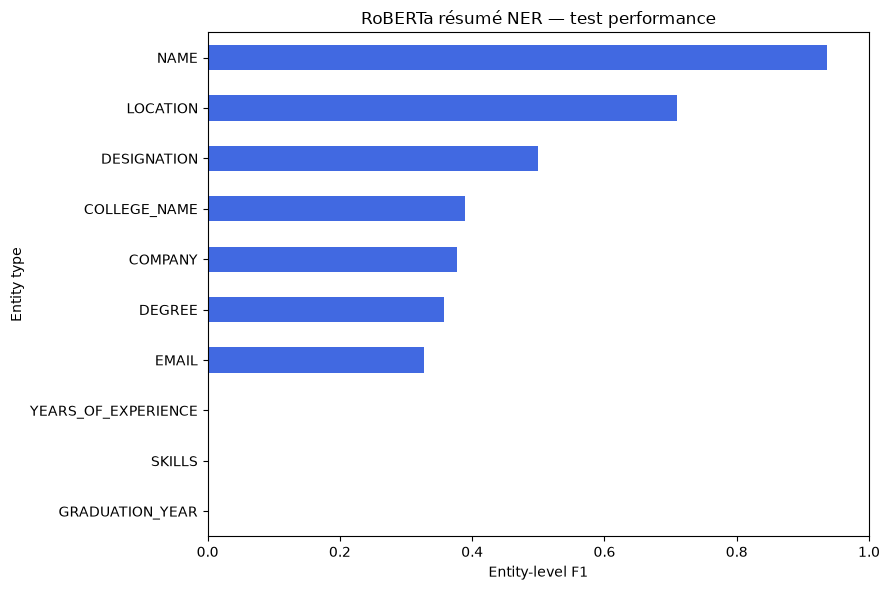

In [ ]:
entity_frame = pd.DataFrame(per_entity).T.sort_values("f1-score")
ax = entity_frame["f1-score"].plot.barh(figsize=(9, 6), color="#4169E1")
ax.set(xlabel="Entity-level F1", ylabel="Entity type", xlim=(0, 1), title="RoBERTa résumé NER — test performance")
plt.tight_layout()
plt.show()

In [ ]:
benchmark_results = {
    "benchmark": "B",
    "model": MODEL_NAME,
    "seed": SEED,
    "split_sizes": {"train": len(train_records), "validation": len(val_records), "test": len(test_records)},
    "overall": overall_metrics,
    "per_entity": per_entity,
}

result_path = RESULTS_DIR / "benchmark_b.json"
with result_path.open("w", encoding="utf-8") as file:
    json.dump(benchmark_results, file, indent=2)

print("Saved metrics to:", result_path)
print("Saved model to:", MODEL_DIR)

Saved metrics to: C:\Users\Owner\Documents\GitHub\NLP-Assignment\results\benchmark_b.json
Saved model to: C:\Users\Owner\Documents\GitHub\NLP-Assignment\models\roberta_resume_ner


### Metric interpretation

- **Precision:** among predicted entities, the proportion whose type and complete span are correct.
- **Recall:** among gold entities, the proportion recovered with the correct type and complete span.
- **F1:** harmonic mean of entity-level precision and recall; use this as the main benchmark score.
- **Accuracy:** token-level correctness. Because most tokens are `O`, accuracy can look strong even when entity extraction is weak.